<a href="https://colab.research.google.com/github/voronv27/projects-in-ai-and-ml/blob/main/Homework4_task1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Task 1 (6000 Level)

###Record Colab Environment:

GPU type: A100  

Seed: use seed 1337 (matching the default seed in train.py, we just do it explicitly as well)

Library versions:

In [1]:
!pip list

Package                                  Version
---------------------------------------- -------------------
absl-py                                  1.4.0
accelerate                               1.12.0
access                                   1.1.10.post3
affine                                   2.4.0
aiofiles                                 24.1.0
aiohappyeyeballs                         2.6.1
aiohttp                                  3.13.3
aiosignal                                1.4.0
aiosqlite                                0.22.1
alabaster                                1.0.0
albucore                                 0.0.24
albumentations                           2.0.8
ale-py                                   0.11.2
alembic                                  1.18.4
altair                                   5.5.0
annotated-doc                            0.0.4
annotated-types                          0.7.0
antlr4-python3-runtime                   4.9.3
anyio                         

##Part A: Train a Small GPT

### Setup

I chose to train the [karpathy/nanoGPT](https://github.com/karpathy/nanoGPT) model.

In [2]:
# clone repo
!pip install torch numpy transformers datasets tiktoken wandb tqdm --quiet
import os

repo_url = "https://github.com/karpathy/nanoGPT"
repo_name = repo_url.split('/')[-1].replace('.git', '')

# Clone the repository if it doesn't already exist
if not os.path.exists(repo_name):
    !git clone {repo_url}
    print(f"Repository '{repo_name}' cloned successfully.")
else:
    print(f"Repository '{repo_name}' already exists. Skipping clone.")



Cloning into 'nanoGPT'...
remote: Enumerating objects: 689, done.
remote: Total 689 (delta 0), reused 0 (delta 0), pack-reused 689 (from 1)
Receiving objects: 100% (689/689), 975.24 KiB | 9.20 MiB/s, done.
Resolving deltas: 100% (382/382), done.
Repository 'nanoGPT' cloned successfully.


I made the following changes to train.py:

add near top of the file to seed the randomness:
```
# fix seed
import random
seed = 1337
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
```

store losses for the loss curve (around line ~260)
```
running_mfu = -1.0
loss_array = [] # ADDED LINE
while True:

    # determine and set the learning rate for this iteration
    lr = get_lr(iter_num) if decay_lr else learning_rate
    for param_group in optimizer.param_groups:
        param_group['lr'] = lr

    # evaluate the loss on train/val sets and write checkpoints
    if iter_num % eval_interval == 0 and master_process:
        losses = estimate_loss()
        loss_array.append(losses) # ADDED CODE LINE
```

plot loss curve (at end of train.py)
```
import matplotlib.pyplot as plt

train_losses = [x['train'] for x in loss_array]
val_losses   = [x['val'] for x in loss_array]

steps = [i * eval_interval for i in range(len(loss_array))]

plt.figure(figsize=(8,5))
plt.plot(steps, train_losses, label='Train Loss')
plt.plot(steps, val_losses, label='Validation Loss')
plt.xlabel('Training Step')
plt.ylabel('Loss')
plt.title('Loss Curve')
plt.legend()
plt.grid(True)
plt.savefig(os.path.join(out_dir, 'loss_curve.png'))
print(f"Saved loss curve to {os.path.join(out_dir, 'loss_curve.png')}")
  ```

In [3]:
# split tiny shakespeare into test/train/validation
%cd nanoGPT
!python data/shakespeare_char/prepare.py

/content/nanoGPT
length of dataset in characters: 1,115,394
all the unique characters: 
 !$&',-.3:;?ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz
vocab size: 65
train has 1,003,854 tokens
val has 111,540 tokens


### Run 1: Train for 5 iterations

Train model:

In [61]:
# train model for 5 epochs
# num_train_tokens = 1,003,854
# batch_size = 64
# block_size = 256
import math
steps_per_epoch = math.floor(1003854 / (64 * 256))
steps = 5*steps_per_epoch

# set log_interval > steps so we avoid printing extra
!python train.py config/train_shakespeare_char.py --max_iters={steps} --device=cuda --eval_interval={steps_per_epoch} --log_interval={steps+1}

Overriding config with config/train_shakespeare_char.py:
# train a miniature character-level shakespeare model
# good for debugging and playing on macbooks and such

out_dir = 'out-shakespeare-char'
eval_interval = 250 # keep frequent because we'll overfit
eval_iters = 200
log_interval = 10 # don't print too too often

# we expect to overfit on this small dataset, so only save when val improves
always_save_checkpoint = False

wandb_log = False # override via command line if you like
wandb_project = 'shakespeare-char'
wandb_run_name = 'mini-gpt'

dataset = 'shakespeare_char'
gradient_accumulation_steps = 1
batch_size = 64
block_size = 256 # context of up to 256 previous characters

# baby GPT model :)
n_layer = 6
n_head = 6
n_embd = 384
dropout = 0.2

learning_rate = 1e-3 # with baby networks can afford to go a bit higher
max_iters = 5000
lr_decay_iters = 5000 # make equal to max_iters usually
min_lr = 1e-4 # learning_rate / 10 usually
beta2 = 0.99 # make a bit bigger because number of 

As seen above, the train loss is 1.8206 and the validation loss is 1.9460 after 5 epochs. Here is the loss curve:

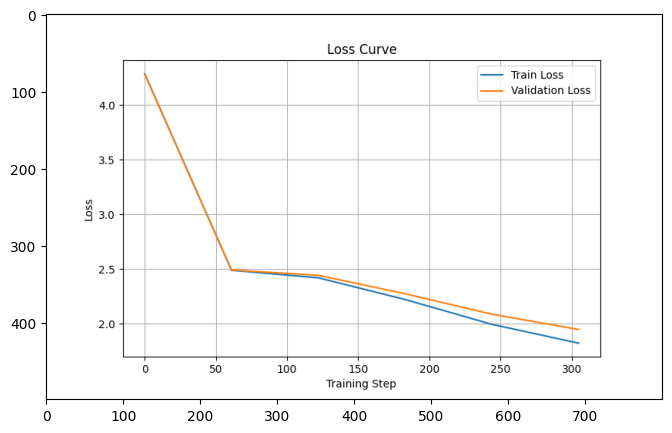

In [63]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

img = mpimg.imread('out-shakespeare-char/loss_curve.png')
plt.figure(figsize=(8, 5))
plt.imshow(img)

In [64]:
# Generate a sample and save it to a file
!python sample.py --num_samples=1 --max_new_tokens=500 --temperature=0.8 --top_k=200 --start="Halt!" --out_dir=out-shakespeare-char > sample_output_5_epoch.txt

# Display the content of the generated sample file
!cat sample_output_5_epoch.txt

Overriding: num_samples = 1
Overriding: max_new_tokens = 500
Overriding: temperature = 0.8
Overriding: top_k = 200
Overriding: start = Halt!
Overriding: out_dir = out-shakespeare-char
number of parameters: 10.65M
Loading meta from data/shakespeare_char/meta.pkl...
Halt! where for ince.

STARUS:
As is a see bube to take rudter:
What not arthich I wear hert?

MEXENIUS:
Whre now he fast, I hown head them of it heart mither;
Whate misee sen con latise in overs,
He him the his armbouself: no me here she cour by stage and all,
If noth all now peak a death thy worly that
And in on her evicks the most rive ceessire sto-shall he rester and thrugh fir armign the fle,
I know of wheir Prien my of that be and the dide
Ardand and aght this he starear tey brouts
Ince a carty
---------------


### Run 2: Train for 50 iterations

In [65]:
steps = 50*steps_per_epoch

# set log_interval > steps so we avoid printing extra
!python train.py config/train_shakespeare_char.py --max_iters={steps} --device=cuda --eval_interval={steps_per_epoch} --log_interval={steps+1}

Overriding config with config/train_shakespeare_char.py:
# train a miniature character-level shakespeare model
# good for debugging and playing on macbooks and such

out_dir = 'out-shakespeare-char'
eval_interval = 250 # keep frequent because we'll overfit
eval_iters = 200
log_interval = 10 # don't print too too often

# we expect to overfit on this small dataset, so only save when val improves
always_save_checkpoint = False

wandb_log = False # override via command line if you like
wandb_project = 'shakespeare-char'
wandb_run_name = 'mini-gpt'

dataset = 'shakespeare_char'
gradient_accumulation_steps = 1
batch_size = 64
block_size = 256 # context of up to 256 previous characters

# baby GPT model :)
n_layer = 6
n_head = 6
n_embd = 384
dropout = 0.2

learning_rate = 1e-3 # with baby networks can afford to go a bit higher
max_iters = 5000
lr_decay_iters = 5000 # make equal to max_iters usually
min_lr = 1e-4 # learning_rate / 10 usually
beta2 = 0.99 # make a bit bigger because number of 

Now train loss is 0.8561 and validation loss is 1.5370.

Loss curve:

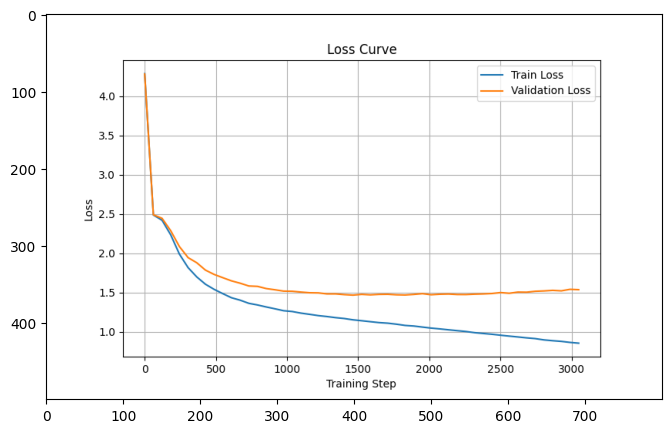

In [66]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

img = mpimg.imread('out-shakespeare-char/loss_curve.png')
plt.figure(figsize=(8, 5))
plt.imshow(img)

In [67]:
# Generate a sample and save it to a file
!python sample.py --num_samples=1 --max_new_tokens=500 --temperature=0.8 --top_k=200 --start="Halt!" --out_dir=out-shakespeare-char > sample_output_50_epoch.txt

# Display the content of the generated sample file
!cat sample_output_50_epoch.txt

Overriding: num_samples = 1
Overriding: max_new_tokens = 500
Overriding: temperature = 0.8
Overriding: top_k = 200
Overriding: start = Halt!
Overriding: out_dir = out-shakespeare-char
number of parameters: 10.65M
Loading meta from data/shakespeare_char/meta.pkl...
Halt!

COMINIUS:
O, we cannot fear me: yet but but that rule
Must I am such as I have been to cry
That tender than themselves of my noble looks,
If it be the world estimates, I heard it
Give my son, and not proceeding self in the little
Thou hast stuff'd i' the years to us.
But therefore, my lords, then,
To Warwick thy high and thy curse and my meeds,
Live the resolution of thy fault;
And thou must pray to the people?

KING HENRY VI:
Harry, my lord!

KING HENRY VI:
Go the quarrel of Gloucester, thoug
---------------


### Run 3: Train for 500 iterations

In [26]:
steps = 500*steps_per_epoch

# set log_interval > steps so we avoid printing extra
!python train.py config/train_shakespeare_char.py --max_iters={steps} --device=cuda --eval_interval={steps_per_epoch} --log_interval={steps+1}

Overriding config with config/train_shakespeare_char.py:
# train a miniature character-level shakespeare model
# good for debugging and playing on macbooks and such

out_dir = 'out-shakespeare-char'
eval_interval = 250 # keep frequent because we'll overfit
eval_iters = 200
log_interval = 10 # don't print too too often

# we expect to overfit on this small dataset, so only save when val improves
always_save_checkpoint = False

wandb_log = False # override via command line if you like
wandb_project = 'shakespeare-char'
wandb_run_name = 'mini-gpt'

dataset = 'shakespeare_char'
gradient_accumulation_steps = 1
batch_size = 64
block_size = 256 # context of up to 256 previous characters

# baby GPT model :)
n_layer = 6
n_head = 6
n_embd = 384
dropout = 0.2

learning_rate = 1e-3 # with baby networks can afford to go a bit higher
max_iters = 5000
lr_decay_iters = 5000 # make equal to max_iters usually
min_lr = 1e-4 # learning_rate / 10 usually
beta2 = 0.99 # make a bit bigger because number of 

For 500 epochs, train loss is 0.1250 and validation loss is 2.5722 (which shows that we have overfitting).

Loss curve:

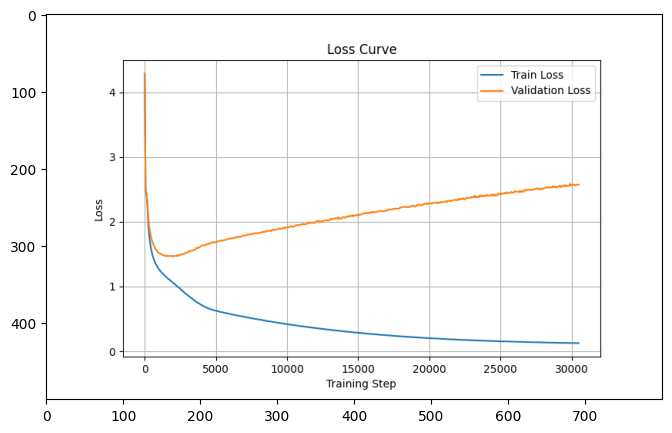

In [27]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

img = mpimg.imread('out-shakespeare-char/loss_curve.png')
plt.figure(figsize=(8, 5))
plt.imshow(img)

In [60]:
# Generate a sample and save it to a file
!python sample.py --num_samples=1 --max_new_tokens=500 --temperature=0.8 --top_k=200 --start="Halt!" --out_dir=out-shakespeare-char > sample_output_500_epoch.txt

# Display the content of the generated sample file
!cat sample_output_500_epoch.txt

Overriding: num_samples = 1
Overriding: max_new_tokens = 500
Overriding: temperature = 0.8
Overriding: top_k = 200
Overriding: start = Halt!
Overriding: out_dir = out-shakespeare-char
number of parameters: 10.65M
Loading meta from data/shakespeare_char/meta.pkl...
Halt!

CLARENCE:
My lord, is not the diseased exceeding rude?

CLARENCE:
You that usurp his back that are sweet my fears
To men our noble Montague and the world.

KING HENRY VI:
Wilt thou die by Saint George of York?

WARWICK:
Now, thou must not speak; and thou yet were strong.

YORK:
Exeter, I think thee on thy head.

YORK:
So thou shalt never mean to come,
Nor under banishment from my kingdom's fearful Edward.

PRINCE EDWARD:
Thou art too fight: disdainted Duke of York.

YORK:
So right I fear the c
---------------


##Part B: Train a Pytorch LSTM Baseline

In [37]:
# copied from train.py
import torch
import numpy as np
block_size = 256
batch_size = 64
dataset = 'shakespeare_char'
device_type = 'cuda' if torch.cuda.is_available() else 'cpu'
device = torch.device(device_type)

# poor man's data loader
data_dir = os.path.join('data', dataset)
def get_batch(split):
    # We recreate np.memmap every batch to avoid a memory leak, as per
    # https://stackoverflow.com/questions/45132940/numpy-memmap-memory-usage-want-to-iterate-once/61472122#61472122
    if split == 'train':
        data = np.memmap(os.path.join(data_dir, 'train.bin'), dtype=np.uint16, mode='r')
    else:
        data = np.memmap(os.path.join(data_dir, 'val.bin'), dtype=np.uint16, mode='r')
    ix = torch.randint(len(data) - block_size, (batch_size,))
    x = torch.stack([torch.from_numpy((data[i:i+block_size]).astype(np.int64)) for i in ix])
    y = torch.stack([torch.from_numpy((data[i+1:i+1+block_size]).astype(np.int64)) for i in ix])
    if device_type == 'cuda':
        # pin arrays x,y, which allows us to move them to GPU asynchronously (non_blocking=True)
        x, y = x.pin_memory().to(device, non_blocking=True), y.pin_memory().to(device, non_blocking=True)
    else:
        x, y = x.to(device), y.to(device)
    return x, y


In [38]:
# LSTM model
import torch.nn as nn
class LSTM(nn.Module):
  def __init__(self, vocab_size, embedding_dim, hidden_dim):
    super().__init__()
    self.embedding = nn.Embedding(vocab_size, embedding_dim)
    self.lstm = nn.LSTM(embedding_dim, hidden_dim, batch_first=True)
    self.linear = nn.Linear(hidden_dim, vocab_size)

  def forward(self, x, h=None):
    embedded = self.embedding(x)
    out, hidden = self.lstm(embedded, h)
    logits = self.linear(out)
    return logits, hidden

In [39]:
# function to generate text from model

# Load meta.pkl generated by prepare.py
import pickle
meta = pickle.load(open('data/shakespeare_char/meta.pkl', 'rb'))
vocab_size = meta['vocab_size']
itos = meta['itos']
stoi = meta['stoi']

def generate_sample_text(model, prompt, num_chars, temperature):
  model.eval()
  idxs = torch.tensor([stoi[c] for c in prompt], device=device).unsqueeze(0)
  hidden = None
  result = prompt

  with torch.no_grad():
    for _ in range(num_chars):
      logits, hidden = model(idxs, hidden)
      logits = logits[:, -1, :] / temperature
      probs = nn.functional.softmax(logits, dim=-1)
      idx = torch.multinomial(probs, num_samples=1)
      result += itos[idx.item()]
      idxs = torch.cat([idxs[:, -block_size:], idx], dim=1)
  return result

In [50]:
# function to train model
def train_model(model, epochs, lr=0.001):
  optimizer = torch.optim.Adam(model.parameters(), lr=lr)
  model.to(device)

  train_loss_array = []
  val_loss_array = []
  for epoch in range(epochs):
    model.train()
    total_loss = 0
    for step in range(steps_per_epoch):
      xb, yb = get_batch('train')
      optimizer.zero_grad()
      logits, _ = model(xb)
      loss = nn.functional.cross_entropy(logits.view(-1, vocab_size), yb.view(-1))
      loss.backward()
      optimizer.step()
      total_loss += loss.item()

    avg_loss = total_loss / steps_per_epoch
    train_loss_array.append(avg_loss)

    model.eval()
    with torch.no_grad():
      xb, yb = get_batch('val')
      logits, _ = model(xb)
      val_loss = nn.functional.cross_entropy(logits.view(-1, vocab_size), yb.view(-1))
      val_loss_array.append(val_loss.item())

  # print final loss at end of training
  num_train_tokens = len(np.memmap(os.path.join(data_dir, 'train.bin'), dtype=np.uint16, mode='r'))
  steps_train = num_train_tokens // (batch_size * block_size)
  num_val_tokens = len(np.memmap(os.path.join(data_dir, 'val.bin'), dtype=np.uint16, mode='r'))
  steps_val = num_val_tokens // (batch_size * block_size)
  total_val_loss = 0.0

  model.eval()
  with torch.no_grad():
    total_train_loss = 0
    for _ in range(steps_train):
      xb, yb = get_batch('train')
      logits, _ = model(xb)
      train_loss = nn.functional.cross_entropy(logits.view(-1, vocab_size), yb.view(-1))
      total_train_loss += train_loss.item()
    train_loss = total_train_loss / steps_train
    print(f"Train loss: {train_loss:.4f}")

    total_val_loss = 0
    for _ in range(steps_val):
      xb, yb = get_batch('val')
      logits, _ = model(xb)
      val_loss = nn.functional.cross_entropy(logits.view(-1, vocab_size), yb.view(-1))
      total_val_loss += val_loss.item()

    val_loss = total_val_loss / steps_val
    print(f"Validation loss: {val_loss:.4f}")

  # get sample text
  text = generate_sample_text(model, "Halt!", 500, temperature=0.8)
  filename = f"lstm_sample_output-{epochs}-epochs.txt"
  with open(filename, 'w') as f:
    f.write(text)
  return train_loss_array, val_loss_array


Train model in 5 epochs
Train loss: 1.7582
Validation loss: 1.8470


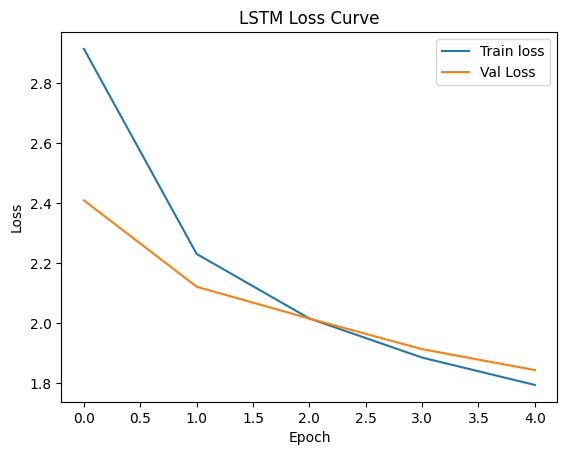

Train model in 50 epochs
Train loss: 1.2488
Validation loss: 1.5218


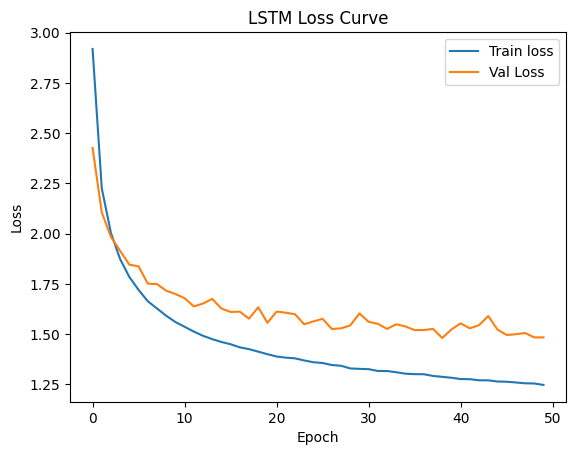

Train model in 500 epochs
Train loss: 0.9504
Validation loss: 1.8519


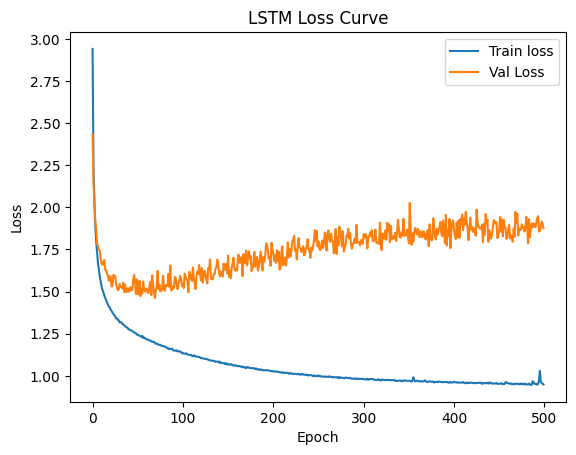

In [51]:
import matplotlib.pyplot as plt

for epoch in [5, 50, 500]:
  print(f"Train model in {epoch} epochs")
  model = LSTM(vocab_size, 128, 256)
  train_loss_array, val_loss_array = train_model(model, epochs=epoch)
  plt.plot(train_loss_array, label="Train loss")
  plt.plot(val_loss_array, label="Val Loss")
  plt.xlabel("Epoch")
  plt.ylabel("Loss")
  plt.title("LSTM Loss Curve")
  plt.legend()
  plt.show()

Text outputs:

In [52]:
!cat lstm_sample_output-5-epochs.txt

Halt! here
The beam his bloutitews, my lord
that know jaduness a mant in this are the plines
Have hathe: your with a with there,
How for him your counters, it you inture;
For of theee as mone or men, thes is and fike the cally
Therepent your dost to he make cauch your a prifes,
Thars and be the word the much to spelion.

BENCANUST:
The eaving thy laken, and trouth the dowar
Shat I meer have face.

MyORK:
So, no dood, and tenen that fillands' appongerd: go carce a mxon to in all-well be so,
Sonate the

In [68]:
!cat lstm_sample_output-50-epochs.txt

Halt!

CAPULET:
What is not the earth, but a hopes and visit it
Untoling in offen there at made,
To take but a better lightness again:
Brother end to him to the ause his rades
Hath been to all unto the way against me air.

KING RICHARD II:
But King Henry's body against a free.

BALTA:
Well be cord; a merry, and posterity
In the common the hopeful woman, were not
hath tunt the wanton and fellows. King Edward false!

QUEEN MARGARET:
Petury is I in this approach of those
Which you are much in the world 

In [70]:
!cat lstm_sample_output-500-epochs.txt

Halt!

KING RICHARD III:
Then you are alloosed for such i' the leaves.

Provost:
Welcome, go, give some sit delight;
But I'll spent; so, some noble lands for them.

KING RICHARD III:
Cousin better dreams of Edward's friend,
And be my death-bed to beat this rain.

DUCHESS OF YORK:
Hishmoar!
Untired his death and nothing are to't,
Which in the honour and her true suffer'd:
He sits of your twicely neck,--an she
should discover all about it not patient.

DUKE VINCENTIO:
What, are you should here not with

##Part C: Comparison Writeup

For 5 epochs, both models were underfitting, resulting in poor coherence and invalid words. In my opinion, the LSTM does a better job at creating coherent text with this many epochs, there are more real words as compared to nanoGPT. Numerically, it also has a lower loss for both train and validation than nanoGPT for 5 epochs.

 As the number of epochs increased, the models started to overfit (especially the nanoGPT). On the 500 epoch loss curve, we can see that the validation loss reached its lowest point fairly early on and then started to climb again, a clear sign of overfitting. The LSTM model also overfit on 500 epochs, though to a lesser extent, as seen by the lower validation loss (and less dramatic climb of the loss curve).

 The 50-epoch trained models were the best fit to the data, minimizing validation loss the most out of the 3 models (for both nanoGPT and LSTM). The nanoGPT model had a lower train loss than the LSTM (when comparing the two 50 epoch models), but their validation losses were fairly similar.

 Coherency-wise, the GPT text (at the higher epochs) was more understandable. As opposed to the LSTM, which seemed to be stringing together random sentences, the GPT sample text had a dialogue-esque flow to it (though still not perfectly coherent). The GPT output was more likely to give the same character more than one dialogue line. I also noticed that (though this may just be a coincidence since I only was comparing 6 files) the GPT model made use of questions in its dialogue, while there were no questions at all in any of the LSTM dialogue.

 The reason that the GPT text felt more coherent was due to the different architecture of the two model types. NanoGPT is a transformer which uses the self-attention mechanism. Each new token can look at all previous tokens within the context window, which is why the sentences seemed less "random" and characters were more likely to be referenced later/given dialogue later after their initial appearance in the output. Meanwhile, the LSTM model requires information to pass through hidden states to get the next token, which means that the model will "compress" the previous tokens and may forget certain details, leading to a more "random" feel in the dialogue (due to character names or context being forgotten). That is, the transformer can look back directly at any token within the context window, while the LSTM relies on the hidden state remembering information from past tokens.

 For a short generation of 500 characters, this gives the GPT a clear advantage, since its block size is 256 characters, meaning it gets to look back at at up to 256 characters of the current output to predict the next token (which is over half the size of the final output!). Meanwhile, the LSTM is more likely to compress and forget information when it passes through the hidden states (though in theory it could remember information from earlier on in the sequence and outperform the transformer in remembering earlier details).